# From Hackathon AI to Production AI

## Chapter 00 — Can It Answer?

Version 2.0

## Story So Far


Saturday morning.

A small team of final-year engineering students gathers for
a weekend hackathon.

Their challenge is ambitious.

Build an AI-powered customer support assistant before
Monday morning.

The application will eventually become HelpDeskAI—a system
that helps customer support teams classify incoming support
tickets.

At this moment, however, none of that exists.

There are no dashboards.

No monitoring.

No evaluation reports.

No deployment plans.

There is only one engineering question that matters.

Can the idea work?

Before solving operational problems, engineers first need
to prove that their solution is technically possible.

## Workshop Context


Throughout this workshop you will gradually transform a
simple AI prototype into a production-oriented AI
application.

Each chapter focuses on a different engineering challenge.

Today, our goal is intentionally modest.

We simply want to build a working prototype that can use
Gemini to understand and classify customer support tickets.

A successful prototype demonstrates possibility.

It does not yet demonstrate production readiness.

## Learning Outcomes

- Create a Gemini API key
- Install the Google GenAI SDK
- Connect to the Gemini API
- Generate AI responses
- Build a reusable prompt function
- Create the first version of HelpDeskAI

## Today's Engineering Question



Can it answer?

## Engineering Principle



A working prototype proves

your idea is possible.

It does not prove

your system is ready.

## The Journey Ahead


Every chapter in this workshop answers one engineering
question.

Today's prototype is only the beginning of a much larger
journey.

Over the coming chapters, we will gradually transform
HelpDeskAI into a production-oriented AI application.

In [ ]:
Hackathon Prototype

↓

Can it answer?

↓

Do we understand it?

↓

Will it survive reality?

↓

Can we trust it?

↓

Would we ship it?

↓

Continuous Improvement

## Engineering Discussion


Many AI projects begin with enthusiasm and curiosity.

The first objective is usually simple:

Can we build something that works?

At this stage, engineers intentionally ignore many
production concerns.

There is little value in designing monitoring dashboards or
deployment strategies for an idea that has not yet been
proven technically feasible.

Prototypes reduce uncertainty by answering the most
fundamental question first.

## Today's Lab


In this notebook you will build the very first version of
HelpDeskAI.

By the end of today's lab, the application will be able to
send prompts to Gemini and classify simple customer support
tickets.

It will be a prototype—not a production system.

That distinction is important.

## Hands-on Exercise 1

### Create a Gemini API Key


Create an API key using Google AI Studio.

Store the key securely.

Never hard-code API keys directly into production
applications.

In [ ]:
from google.colab import userdata

API_KEY = userdata.get("GOOGLE_API_KEY")

print("API key loaded successfully.")

## Reflection


API keys provide access to cloud services on your behalf.

Treat them like passwords.

Good engineering practices begin with protecting credentials
and keeping secrets out of source code.

## Hands-on Exercise 2

### Install the Google GenAI SDK


Install the official Python SDK used throughout this
workshop.

In [ ]:
%pip install -q -U google-genai

## Hands-on Exercise 3

### Import the SDK


Import the classes required to communicate with Gemini.

In [ ]:
from google import genai

## Hands-on Exercise 4

### Create a Gemini Client


Create a reusable client object that will communicate with
the Gemini API.

In [ ]:
client = genai.Client(
    api_key=API_KEY
)

print("Client created successfully.")

## Engineering Discussion


The client object represents your application's connection
to Gemini.

Rather than repeatedly configuring authentication for every
request, engineers create the client once and reuse it
throughout the application.

Small design decisions like this improve readability and
maintainability as projects grow.

## Reflection


Everything is now in place.

The SDK is installed.

The client is configured.

The next step is the moment every AI developer looks
forward to—sending the first prompt to the model.

If the model responds successfully, our prototype becomes
real.

## Hands-on Exercise 5

### Generate Your First Response


Send a simple prompt to Gemini and display the generated
response.

In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain what artificial intelligence is in two sentences."
)

print(response.text)

## Engineering Discussion


Congratulations—you have successfully communicated with a
large language model.

Although this example is simple, it proves that the core
technology works.

This is exactly what a prototype is meant to demonstrate:
technical feasibility.

## Hands-on Exercise 6

### Experiment with Prompts


Modify the prompt and observe how the model responds.

Try asking for different styles, formats, or levels of
detail.

In [ ]:
prompt = '''
Explain cloud computing

using exactly three bullet points.
'''

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(response.text)

## Reflection


Notice that changing only the prompt can significantly
change the response.

Prompt design is one of the simplest ways to influence model
behaviour without changing the underlying application.

## Hands-on Exercise 7

### Introduce HelpDeskAI


Instead of asking general questions, begin solving the
problem our hackathon team set out to address.

We want Gemini to classify customer support tickets into
three categories.

Billing

Technical

Account

In [ ]:
ticket = '''
I was charged twice for my monthly subscription.
'''

prompt = f'''
You are a customer support assistant.

Classify the following support ticket into exactly one of
these categories.

Billing

Technical

Account

Return only the category.

Ticket

{ticket}
'''

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(response.text)

## Engineering Discussion


Our prototype now performs a meaningful business task.

Rather than generating general-purpose text, it helps route
customer support requests.

Even a simple prototype can create value when it addresses a
real problem.

## Hands-on Exercise 8

### Build a Reusable Function


Avoid repeating the same prompt every time.

Wrap the classification logic inside a reusable function.

In [ ]:
def classify_ticket(ticket):

    prompt = f'''
You are HelpDeskAI.

Classify the customer support ticket into exactly one of
these categories.

Billing

Technical

Account

Return only the category.

Ticket

{ticket}
'''

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text.strip()

## Hands-on Exercise 9

### Classify Multiple Tickets


Reuse the function with several different customer support
requests.

In [ ]:
tickets = [

    "I forgot my password and cannot sign in.",

    "The application crashes whenever I upload a file.",

    "Please refund my last payment."

]

for ticket in tickets:

    print("-" * 60)
    print(ticket)
    print()
    print(classify_ticket(ticket))
    print()

## Reflection


Reusable functions make applications easier to maintain.

If the prompt needs to change later, there is only one place
to update it.

This is a simple example of designing software for future
change.

## Hands-on Exercise 10

### Refine the Prompt


Improve the prompt by making the instructions clearer.

Experiment with:

• more explicit instructions

• different wording

• additional context

Observe how the responses change.

In [ ]:
# Modify the prompt inside classify_ticket()

# Experiment with different instructions.

# Which version produces the most consistent results?

## Think Like an Engineer


A prototype is not expected to solve every problem.

Its purpose is to answer one important question.

Can this idea work?

Once the answer is yes, engineers can begin improving the
system step by step.

## Challenge Exercise


Your hackathon team wants to improve HelpDeskAI before the
demo.

Experiment with your classifier by:

• adding more customer tickets

• rewriting the prompt

• introducing new ticket wording

• testing edge cases

Remember that there is no single perfect prompt.

Experimentation is an important part of prototyping.

## Engineering Discussion


Hackathons encourage rapid experimentation.

Speed is valuable because it allows teams to validate ideas
quickly.

At this stage, success is measured by learning rather than
perfection.

The prototype gives the team confidence that the idea is
worth pursuing further.

## Reflection


Notice what we have not built yet.

We do not know how often the application succeeds.

We do not know how long requests take.

We cannot explain unexpected behaviour.

We have no way to monitor the application after deployment.

Those questions become important only after a working
prototype exists.

## Checkpoint


HelpDeskAI can now

• connect to Gemini

• send prompts

• receive AI-generated responses

• classify customer support tickets

• reuse prompts through a Python function

You have successfully built a working AI prototype.

The idea has been proven technically feasible.

## Chapter Summary


In this chapter you built the first version of HelpDeskAI.

Starting with a Gemini API key and the Google GenAI SDK, you
created a simple application capable of classifying customer
support tickets.

Along the way you learned how prompts influence model
behaviour and how reusable functions make applications
easier to maintain.

Most importantly, you answered the first engineering
question.

Can it answer?

The answer is yes.

But a working prototype is only the beginning of the
engineering journey.

## Production Readiness Checklist

Completed

☑ Working AI prototype
☑ Gemini API integration
☑ Prompt design
☑ Reusable prompt function
☑ Customer ticket classification

Still Missing

☐ Observability
☐ Logging
☐ Reliability
☐ Input validation
☐ Evaluation
☐ Monitoring
☐ Deployment strategy

## Looking Ahead

### Chapter 01 — Do We Understand It?


HelpDeskAI works.

But imagine the application suddenly becomes slower.

Or starts producing unexpected answers.

Or different team members begin experimenting with new
prompts.

How would you understand what the application is doing?

The next chapter introduces observability—the engineering
practice of measuring and understanding system behaviour.

You cannot improve what you cannot observe.

## Reflection


Today's achievement is significant.

Every production AI application begins with a successful
prototype.

Without a working prototype, there is nothing to improve.

But prototypes answer only one engineering question.

Over the coming chapters, you will discover that production
AI requires much more than successful API calls.

It requires understanding the system, preparing for failure,
measuring quality, and making responsible deployment
decisions.

That journey begins next.

---

## Problem Lens

> ### Fall in love with the problem, not the solution.

We are not building an AI classifier because the technology is interesting.

We are exploring AI classification because customer-support teams spend time manually routing incoming tickets.

**The problem is the anchor. The solution is a hypothesis.**

As we learn more, the solution may change.

### In this chapter

**Problem** → Manual ticket routing  
**Solution we're exploring** → AI-assisted classification  
**What we're learning** → Can the idea work?  
---
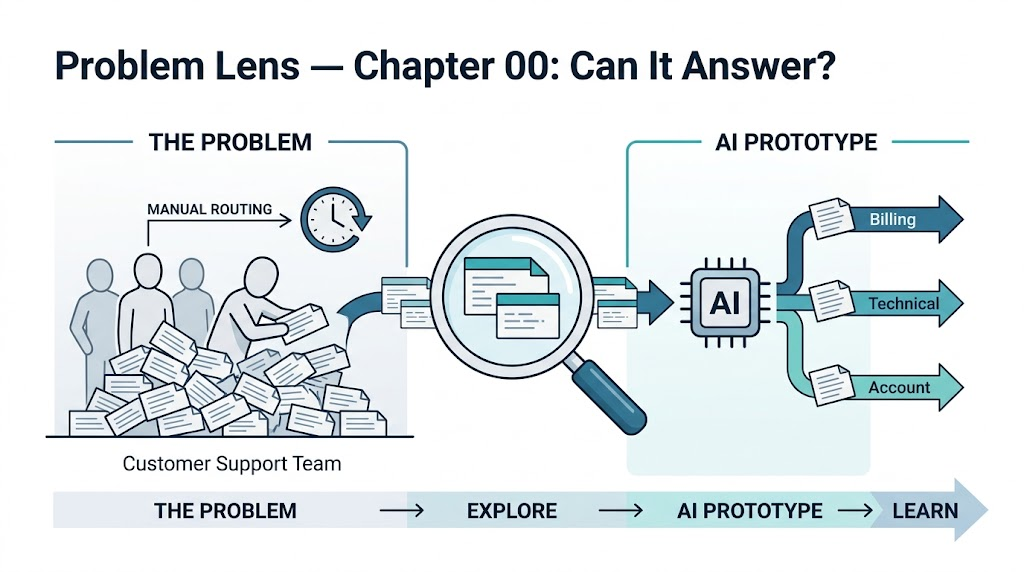